In [1]:
import pandas as pd

# ==========================================
# 1. CARICAMENTO DEI DATI
# ==========================================

In [7]:
# Sostituisci i nomi con i percorsi reali dei tuoi file CSV.
# L'argomento 'index_col=0' è FONDAMENTALE in bioinformatica: dice a Pandas 
# che la prima colonna non è un dato, ma l'ID (il nome) del paziente o del batterio.
print("Caricamento dei dataset in corso...")

# X = Tabella delle abbondanze (Pazienti x Batteri)
df_X = pd.read_csv("Abbondanze_CRC_Dataset.csv", index_col=0).T

# y = Tabella dei metadati (Pazienti x Informazioni cliniche, es. CRC/Sano)
df_y = pd.read_csv("Metadati_CRC_Dataset.csv", index_col=0)

Caricamento dei dataset in corso...


# ==========================================
# 2. PRIMA ISPEZIONE (Sanity Check)
# ==========================================

In [8]:
print("\n--- Dimensioni Iniziali ---")
print(f"Matrice Batteri (X) Trasposta: {df_X.shape[0]} righe (pazienti) e {df_X.shape[1]} colonne (batteri/feature)")
print(f"Matrice Metadati (y): {df_y.shape[0]} righe (pazienti) e {df_y.shape[1]} colonne (variabili cliniche)")


--- Dimensioni Iniziali ---
Matrice Batteri (X) Trasposta: 1395 righe (pazienti) e 934 colonne (batteri/feature)
Matrice Metadati (y): 1395 righe (pazienti) e 140 colonne (variabili cliniche)


# ==========================================
# 3. ALLINEAMENTO DEGLI INDICI (Il trucco salva-vita)
# ==========================================
# Spesso nei dataset reali ci sono pazienti di cui abbiamo il DNA ma non la cartella clinica, o viceversa.
# Se passiamo dati disallineati alla PCA, l'algoritmo ci restituisce grafici completamente falsati.

In [9]:
# Troviamo l'intersezione perfetta: i pazienti (ID) che esistono in ENTRAMBE le tabelle
pazienti_in_comune = df_X.index.intersection(df_y.index)
print(f"\nPazienti validi trovati in entrambe le tabelle: {len(pazienti_in_comune)}")

# Sovrascriviamo i DataFrame tenendo SOLO i pazienti in comune.
# Usare .loc garantisce anche che l'ordine delle righe sia ora IDENTICO tra X e y.
df_X_clean = df_X.loc[pazienti_in_comune]
df_y_clean = df_y.loc[pazienti_in_comune]


Pazienti validi trovati in entrambe le tabelle: 1395


In [10]:
print("\n--- Dimensioni Post-Allineamento ---")
print("Nuova X:", df_X_clean.shape)
print("Nuova y:", df_y_clean.shape)


--- Dimensioni Post-Allineamento ---
Nuova X: (1395, 934)
Nuova y: (1395, 140)


In [11]:
# Piccola preview dei primi 5 pazienti
print("\nPrime 5 righe dei metadati allineati:")
print(df_y_clean.head())


Prime 5 righe dei metadati allineati:
          study_name subject_id body_site antibiotics_current_use  \
SID31004  FengQ_2015   SID31004     stool                      no   
SID31009  FengQ_2015   SID31009     stool                      no   
SID31021  FengQ_2015   SID31021     stool                      no   
SID31071  FengQ_2015   SID31071     stool                      no   
SID31112  FengQ_2015   SID31112     stool                      no   

         study_condition                       disease   age age_category  \
SID31004             CRC  CRC;fatty_liver;hypertension  64.0        adult   
SID31009         control      fatty_liver;hypertension  68.0       senior   
SID31021         control                       healthy  60.0        adult   
SID31071         control                   fatty_liver  68.0       senior   
SID31112         control                   fatty_liver  66.0       senior   

          gender country  ... hla_dqa11 hla_drb11 birth_order  \
SID31004    male  

# ==========================================
# Filtro della prevalenza (eliminiamo i batteri rari)
# ==========================================

In [15]:
bool_X = df_X_clean>0
bact_perc = bool_X.mean(axis=0)
bact_filt = bact_perc>0.05
df_X_filtered = df_X_clean.loc[:, bact_filt]
print("Dimensioni dopo il filtro:", df_X_filtered.shape)

Dimensioni dopo il filtro: (1395, 295)


# ==========================================
# Esplorazione visiva (grafico a barre)
# ==========================================

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
study_condition = df_y_clean['study_condition'].value_counts()
print(study_condition)

study_condition
CRC        701
control    694
Name: count, dtype: int64


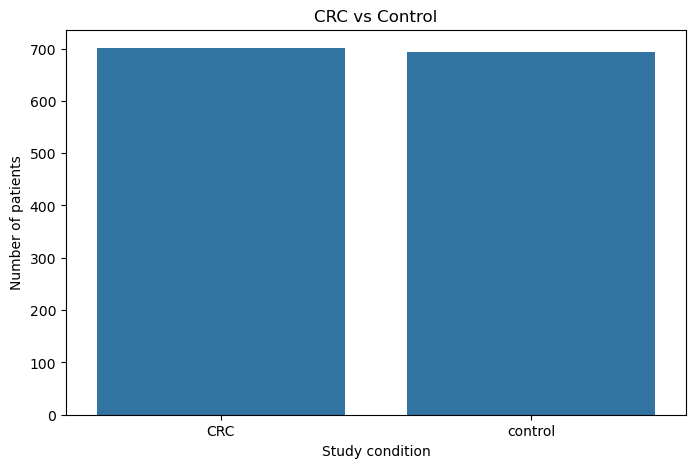

In [25]:
plot = plt.figure(figsize=(8, 5))
sns.countplot(data=df_y_clean,x='study_condition')
plt.title("CRC vs Control")
plt.xlabel("Study condition")
plt.ylabel("Number of patients")
plt.show()